# A single-band approximation for La$_{2}$CuO$_{4}$: Metal-insulator transitions

In this tutorial, we extend our study of La$_{2}$CuO$_{4}$ by exploring how electron correlations drive a metal-insulator transition within the DMFT framework. Starting from the effective low-energy model built in the previous tutorial, we will increase the strength of the Hubbard interaction $U$, rerun the DMFT calculation, and analyze how the spectral function evolves from metallic to insulating behavior.

Specifically, you will learn how to analyze how the local spectral function change across the metal-insulator transition.

### 🧪 Exercise 0: Write a generic DMFT function
Let's turn our DMFT loop that we wrote in [Tutorial X]() into a free function that takes as argument a few parameters. We can then use this function to effectively explore parameter spaces. For example, we would like to study the metal-insulator transition of La$_{2}CuO$_{4}$ wihtin our single-band approximation for this material.

#### 🧩 Your Task
Write a function called ``solve_dmft_equations`` with the following api:

```python
def solve_dmft_equations(target_density, # total electron density
                         beta,           # inverse temperature
                         obe,            # one-body elements
                         E,              # embedding
                         h_int,          # interaction hamiltonian
                         solver,         # impurity solver
                         solver_params,  # solver parameters
                         bz_int=modest.BzIntOptions(), # integration options
                         n_dmft_loops=15, # number of DMFT loops
                         n_iw=251):      # number of Matsubara points
    """
    your implementation
    """
    return mu, solver_results
```

In [1]:
import triqs_modest as modest
from triqs.gf import MeshImFreq

def solve_dmft_equations(target_density, # total electron density
                         beta,           # inverse temperature
                         obe,            # one-body elements
                         E,              # embedding
                         h_int,          # interaction hamiltonian
                         solver,         # impurity solver
                         solver_params,  # solver parameters
                         bz_int=modest.BzIntOptions(), # integration options
                         n_dmft_loops=15, # number of DMFT loops
                         n_iw=251):      # number of Matsubara points
    
    # Matsubara mesh
    mesh = MeshImFreq(beta, S='Fermion', n_iw=n_iw)

    # set up self-energy Sigma = 0 (see Exercise 3)
    Sigma_imp_dynamic, Sigma_imp_static = E.make_zero_imp_self_energies(mesh)[0]

    # DMFT loop
    for n_iter in range(n_dmft_loops):

        # embed self-energy
        Sigma_C_dynamic, Sigma_C_static = E.embed([Sigma_imp_dynamic], [Sigma_imp_static])

        # find mu
        mu = modest.find_chemical_potential(target_density, obe, Sigma_C_dynamic, Sigma_C_static, bz_int, verbosity=False)

        # compute the local Green's function
        Gloc = E.extract(modest.gloc(obe, mu, Sigma_C_dynamic, Sigma_C_static, bz_int))[0]

        # compute impurity levels
        hloc0 = E.extract(modest.impurity_levels(obe) - mu)[0]

        # compute hybridization function
        Delta_iw = modest.hybridization(hloc0, Gloc, Sigma_imp_dynamic, Sigma_imp_static)
    
        # solve impurity problem
        solver_results = solver(Delta_iw, hloc0, h_int, **solver_params)

        print(f"Δn = |n_lattice - n_impurity| = {abs(Gloc.total_density()-solver_results.G_iw.total_density())}")

        # update the impurity self-energy
        Sigma_imp_dynamic, Sigma_imp_static = solver_results.Sigma_dynamic, solver_results.Sigma_Hartree  

    return mu, solver_results

### 🧪 Exercise 1: Set up the data for your DMFT solver

Let's now use our function to run a new DMFT calculation with an increased Coulomb interaction $U$. Let's try $U = 5$ eV. Your function takes the following parameters:

1. target electron density
2. inverse temperature 
3. one-body elements
4. an embedding description
5. interaction Hamiltonian
6. a solver
7. solver parameters

Start by appropriately initializing all of this data.

In [2]:
from triqs.operators import n

# electron density
target_density    = 1.0

# inverse temperature
beta = 10.0

# obe
obe  = modest.one_body_elements_from_wannier90("./data/mlwf/lco", # wannier file path
                                               "NonPolarized",  # spin kind
                                               [modest.AtomicShellT(dft_idx=0, cls_idx=0, l=2, dim=1)] # orbital(s)
                                              )
# embedding
E = modest.make_embedding(obe.C_space)

# interaction
U = 5.0
h_int = U*n('up_0',0)*n('down_0',0)

# my solver is cthyb_solve
from utils.solvers import solve as cthyb_solve

# solver parameters
solver_params = dict(length_cycle=80, n_cycles = int(1e+6), n_warmup_cycles = int(1e+3), 
                     perform_tail_fit=True, fit_min_w=5, fit_max_w=9, imag_threshold = 1e-6)

Starting serial run at: 2025-08-10 09:52:15.518219


## 🔍 Finding the metal-insulator transition

### 🧪 Exercise 2: Test your DMFT function

Now that we have our data call the DMFT function you wrote in the first Exercise. Let's use ``n_dmft_loops=2`` to make sure everything is running properly.

In [3]:
mu, solver_results = solve_dmft_equations(target_density, beta, obe, E, h_int, cthyb_solve, solver_params, n_dmft_loops=2)


╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
0.0898123*c_dag('down_0',0)*c('down_0',0) + 0.0898123*c_dag('up_0',0)*c('up_0',0) + 5*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
09:53:14 100% ETA 00:00:00 cycle 999 of 1000



Accumulating ...
09:53:14   0% ETA 00:01:08 cycle 1463 of 1000000
09:53:16   3% ETA 00:01:05 cycle 31337 of 1000000
09:53:19   6% ETA 00:01:03 cycle 68491 of 1000000
09:53:22  11% ETA 00:01:00 cycle 115009 of 1000000
09:53:26  17% ETA 00:00:56 cycle 173213 of 1000000
09:53:31  24% ETA 00:00:51 cycle 245677 of 1000000
09:53:37  33% ETA 00:00:45 cycle 335652 of 1000000
09:53:45  44% ETA 00:00:37 cycle 448492 of 1000000
09:53:55  58% ETA 00:00:28 cycle 588222 of 1000000
09:54:07  76% ETA 00:00:15 cycle 767655 of 1000000
09:54:22  98% ETA 00:00:00 cycle 989636 of 10

### 🧪 Exercise 3: Check your Green's function and self-energy

Let's plot our current Green's function and self-energy after a couple of DMFT iterations.

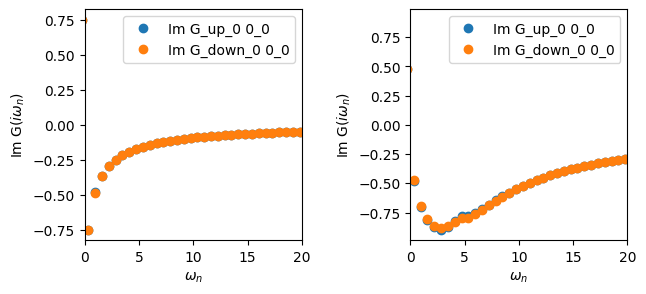

In [4]:
from triqs.plot.mpl_interface import oplot, plt
fig, ax = plt.subplots(1,2,sharex=True, figsize=(7,3))
ax[0].oplot(solver_results.G_iw.imag, 'o')
ax[1].oplot(solver_results.Sigma_iw.imag, 'o')
ax[0].set_xlim(0,20)
plt.subplots_adjust(wspace=0.5)
plt.show()

### 🧪 Exercise 4: Load converged reference data

In the interest of time, let's load pre-converged DMFT data for this $U$ value. You can load the reference data from the file ``lco-beta=10.0-U=5.0.h5`` in the ``ref_data`` directory.

In [5]:
from h5 import HDFArchive
from triqs.gf import MeshImFreq, BlockGf

with HDFArchive('ref_data/lco-beta=10.0-U=5.0.h5') as ar:
    last_iter = str(len(ar)-1)
    mu = ar[last_iter]['mu']
    Sigma_iw = ar[last_iter]['Sigma_iw']
    G_iw = ar[last_iter]['G_iw']

### 🧪 Exercise 5: Plot converged results

Now let's plot the imaginary part of the converged Green's function and self-energy.

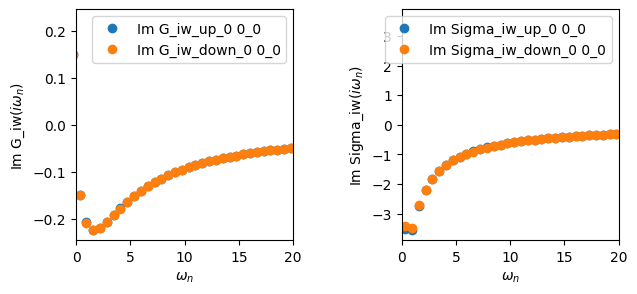

In [6]:
from triqs.plot.mpl_interface import oplot, plt
fig, ax = plt.subplots(1,2,sharex=True, figsize=(7,3))
ax[0].oplot(G_iw.imag, 'o')
ax[1].oplot(Sigma_iw.imag, 'o')
ax[0].set_xlim(0,20)
plt.subplots_adjust(wspace=0.5)
plt.show()

### 🧪 Exercise 6: Compare and contrast

Compare and contrast the converged results to your previous result obtained at lower values of $U$. What are the qualitative differences between the Green's function and self-energy at these two values of $U$.

For $U = 3.6$ eV, we saw that the Green's function was finite as $\omega_{n}\rightarrow 0$, while for the $U = 5$ eV results we see that the Green's function as an upturn at low $U$ indicating the suppression of spectral weight at the Fermi level and therefore the opening of a Mott gap. Similarly, the imaginary part of the self-energy is diverging as $\omega_{n}\rightarrow 0$ goes to zero for the larger value of $U$, while for smaller value of $U$ the self-energy show metallic behavior.

### 🧪 Exercise 7: Real-frequency spectral function

Let's analytically continue our converged Green's function and plot the resulting spectral function.

In [7]:
from utils.maxent import Aw_from_maxent

mesh, Aw = Aw_from_maxent(G_iw, omega_min=-10, omega_max=10,
                          alpha_min=1e-2, alpha_max=1e2, 
                          n_alpha_points=50, n_omega_points=250, 
                          error=0.06)

Calculating diagonal elements.
Calling MaxEnt for element 0 0
2025-08-10 09:55:29.441511
MaxEnt run
TRIQS application maxent
Copyright(C) 2018 Gernot J. Kraberger
Copyright(C) 2018 Simons Foundation
Authors: Gernot J. Kraberger and Manuel Zingl
This program comes with ABSOLUTELY NO WARRANTY.
This is free software, and you are welcome to redistributeit under certain conditions; see file LICENSE.
Please cite this code and the appropriate original papers (see documentation).

Minimal chi2: 8.040571229108438e-05
scaling alpha by a factor 1507 (number of data points)
alpha[ 0] =   1.50700000e+05, chi2 =   4.86493102e+02, n_iter=       4 
alpha[ 1] =   1.24876466e+05, chi2 =   4.83426171e+02, n_iter=       3 
alpha[ 2] =   1.03477981e+05, chi2 =   4.79774921e+02, n_iter=       3 
alpha[ 3] =   8.57462811e+04, chi2 =   4.75440067e+02, n_iter=       3 
alpha[ 4] =   7.10530361e+04, chi2 =   4.70310727e+02, n_iter=       3 
alpha[ 5] =   5.88775849e+04, chi2 =   4.64265463e+02, n_iter=       3 

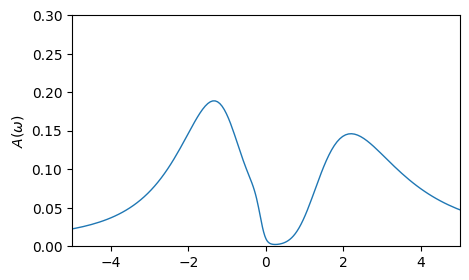

In [8]:
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(mesh, Aw['up_0'].get_A_out('LineFitAnalyzer')[0,0].real, lw=1)
ax.set_ylabel(r'$A(\omega)$'); ax.set_xlim(-5,5); ax.set_ylim(0, 0.3)
plt.show()

### 🧪 Exercise 8: Real-frequency self-energy

Let's analytically continue our converged self-energy and plot it.

In [9]:
from utils.maxent import Sigma_w_from_maxent

Sigma_w = Sigma_w_from_maxent(Sigma_iw, error=0.04)

Calculating diagonal elements.
Calling MaxEnt for element 0 0
2025-08-10 09:55:30.338556
MaxEnt run
TRIQS application maxent
Copyright(C) 2018 Gernot J. Kraberger
Copyright(C) 2018 Simons Foundation
Authors: Gernot J. Kraberger and Manuel Zingl
This program comes with ABSOLUTELY NO WARRANTY.
This is free software, and you are welcome to redistributeit under certain conditions; see file LICENSE.
Please cite this code and the appropriate original papers (see documentation).

Minimal chi2: 0.00023141174915792132
scaling alpha by a factor 1507 (number of data points)
alpha[ 0] =   1.50700000e+05, chi2 =   1.50769761e+03, n_iter=       4 
alpha[ 1] =   1.03477981e+05, chi2 =   1.47498918e+03, n_iter=       3 
alpha[ 2] =   7.10530361e+04, chi2 =   1.43039389e+03, n_iter=       3 
alpha[ 3] =   4.87884852e+04, chi2 =   1.37119577e+03, n_iter=       3 
alpha[ 4] =   3.35005570e+04, chi2 =   1.29530773e+03, n_iter=       3 
alpha[ 5] =   2.30031188e+04, chi2 =   1.20207796e+03, n_iter=       3

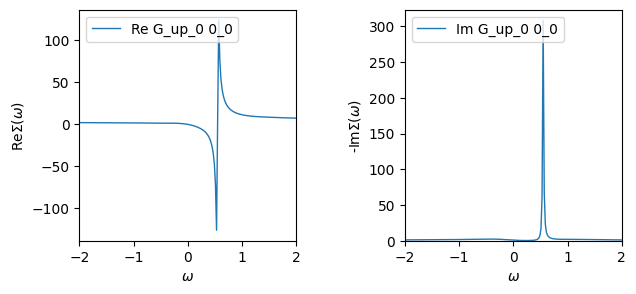

In [10]:
fig, ax = plt.subplots(1,2,sharex=True, figsize=(7,3))
# maxent
ax[0].oplot(Sigma_w['up_0']-Sigma_w['up_0'][0,0](0.0).real, mode='R', lw=1)
ax[1].oplot(-Sigma_w['up_0'], mode='I', lw=1)
ax[0].legend(loc='upper left'); ax[1].legend(loc='upper left')
ax[0].set_xlim(-2,2); ax[1].set_ylim(0, ); 
ax[0].set_ylabel(r'Re$\Sigma(\omega)$'); ax[1].set_ylabel(r'-Im$\Sigma(\omega)$')
plt.subplots_adjust(wspace=0.5)
plt.show()

### 🧪 Exercise 9: Real-frequency spectrum along high-symmetry lines

Finally, let's use our real-frequency self-energy to obtain our spectral function along high-symmetry lines in the Brillouin zone.

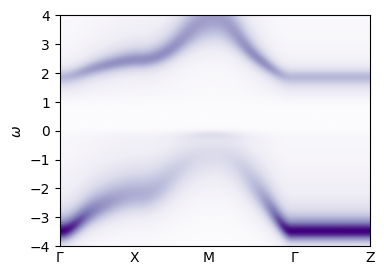

In [11]:
import triqs_modest as modest
from triqs.lattice.utils import k_space_path
from utils.mpl_interface import *

# create high-symmetry path
G = [0.00,  0.00,  0.00]
X = [0.25, -0.25,  0.25]
M = [0.00,  0.00,  0.50]
Z = [0.25,  0.25, -0.25]

segments = [(G,X), (X,M), (M, G), (G,Z)]
k_points, k_lin, k_ticks = k_space_path(segments)


# load in obe or the TB hamiltonian
obe  = modest.one_body_elements_from_wannier90("./data/mlwf/lco", 
                                               "NonPolarized", 
                                               [modest.AtomicShellT(dft_idx=0, cls_idx=0, l=2, dim=1)])

# compute the disperion along the high-symmetry directions
e_k = obe.H[0].eigenvalues(k_points).real

# compute the spectral function
A_kw = momentum_resolved_spectral_function(e_k, mu, Sigma_w['up_0'], broadening=0.1)

fig, ax = plt.subplots(figsize=(4,3))

# plot the spectral function
ax.plot_spectral_function(A_kw, k_lin, k_ticks, [r'$\Gamma$', 'X', 'M', r'$\Gamma$', 'Z'], cmap='Purples', vmin=0)

ax.set_ylim(-4,4)
plt.show()